# Multi-Modal ALS Classification: CNN Training & Visualization

## Overview
This notebook focuses on **Step 1** of our pipeline: Training the **3D Convolutional Neural Networks (CNNs)**.

### Goal
We aim to train independent feature extractors for three MRI modalities:
1.  **T1-weighted** (Anatomy)
2.  **T2-weighted** (Pathology/Fluid)
3.  **FLAIR** (Lesions/Inflammation)

To ensure these CNNs learn meaningful features, we train them in a supervised manner to classify **ALS vs. Control**. Once trained, these encoders will be frozen and used to extract features for the subsequent Vision Transformer (ViT) stage.

### Outputs
*   **Training Metrics**: Loss and Accuracy curves.
*   **Visualization**: Grad-CAM heatmaps showing which brain regions the CNNs focus on (saved as PNG and 3D NIfTI).
*   **Saved Model**: The trained encoder weights will be saved for the feature extraction step.

In [ ]:
!pip install torch torchvision torchaudio numpy nibabel scipy matplotlib tqdm ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.0 MB/s eta 0:00:00


In [ ]:
# Imports
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import torch.nn.functional as F
from scipy.ndimage import zoom
import nibabel as nib
from tqdm.notebook import tqdm

# Environment Check
try:
    from google.colab import drive
    drive.mount('/content/drive')
    # Change this path to point to the 'cnnModelMultiModality' directory within your Drive
    PROJECT_PATH = '/content/drive/MyDrive/Deep-learning-ALS/src/cnnModelMultiModality'
    if os.path.exists(PROJECT_PATH):
        os.chdir(PROJECT_PATH)
        print(f"Colab Environment: Detected. Working in {PROJECT_PATH}")
    else:
        print(f"Warning: Path {PROJECT_PATH} does not exist.")
except ImportError:
    print("Local Environment: Detected")

# Add current directory to path to allow importing local modules
# This is critical for loading dataset.py and featureExtractor.py
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

# Import Helper Modules
try:
    from dataset import MultiModalALSDataset
    from featureExtractor import SingleModalityEncoder
    from classifier import ALSTriStreamClassifier
    print("Successfully imported helper modules.")
except ImportError as e:
    print(f"Error importing modules: {e}")
    print("Ensure you are running this notebook from the 'cnnModelMultiModality' directory.")

# Device Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {DEVICE}")

Mounted at /content/drive
Colab Environment: Detected. Working in /content/drive/MyDrive/Deep-learning-ALS/src/cnnModelMultiModality
Successfully imported helper modules.
Device: cpu


## Training the CNNs

We use a combined training approach:
1.  Pass T1, T2, and FLAIR images through their respective encoders.
2.  Concatenate the output vectors.
3.  Pass through a simple linear layer to predict the label.
4.  Backpropagate to update the encoder weights.

This forces each encoder to learn relevant features that contribute to the diagnosis.

In [ ]:
# Configuration
DATA_DIR = "../../Data/processed"
CHECKPOINT_DIR = "../cnn_features"  # Updated output directory
BATCH_SIZE = 4
LR = 1e-4
EPOCHS = 1

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# DEBUGGING: Verify Data Path
abs_data_path = os.path.abspath(DATA_DIR)
print(f"Looking for data in: {abs_data_path}")

if os.path.exists(abs_data_path):
    print("Data directory exists.")
    subjects = [d for d in os.listdir(abs_data_path) if os.path.isdir(os.path.join(abs_data_path, d))]
    print(f"Found {len(subjects)} subdirectories (potential subjects).")
    if len(subjects) > 0:
        print(f"First 5 folders: {subjects[:5]}")
else:
    print("Data directory DOES NOT exist. Please check relative path.")

# Dataset
if os.path.exists(DATA_DIR):
    dataset = MultiModalALSDataset(rootDirectory=DATA_DIR)

    print(f"Dataset Initialized. Found {len(dataset)} valid samples.")

    if len(dataset) > 0:
        train_size = int(0.8 * len(dataset))
        val_size = len(dataset) - train_size
        train_set, val_set = random_split(dataset, [train_size, val_size])

        train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

        print(f"Data Loaded: {len(train_set)} Train, {len(val_set)} Val")

        # Model Setup - Using the TriStream Classifier
        print("Initializing ALSTriStreamClassifier...")
        model = ALSTriStreamClassifier().to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=LR)
        criterion = nn.BCEWithLogitsLoss()

        # Scheduler: Reduce LR if validation loss plateaus
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

        # Metrics Storage
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

        # Training Loop
        print("Starting Training...")
        best_val_acc = 0.0

        for epoch in range(EPOCHS):
            model.train()
            running_loss = 0.0
            correct = 0
            total = 0

            for (t1, t2, flair), label in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
                t1, t2, flair = t1.to(DEVICE), t2.to(DEVICE), flair.to(DEVICE)
                label = label.to(DEVICE).unsqueeze(1)

                optimizer.zero_grad()
                output = model(t1, t2, flair)
                loss = criterion(output, label)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                preds = torch.sigmoid(output) > 0.5
                correct += (preds == label).sum().item()
                total += label.size(0)

            epoch_loss = running_loss / len(train_loader)
            epoch_acc = correct / total
            history['train_loss'].append(epoch_loss)
            history['train_acc'].append(epoch_acc)

            # Validation
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            with torch.no_grad():
                for (t1, t2, flair), label in val_loader:
                    t1, t2, flair = t1.to(DEVICE), t2.to(DEVICE), flair.to(DEVICE)
                    label = label.to(DEVICE).unsqueeze(1)

                    output = model(t1, t2, flair)
                    loss = criterion(output, label)

                    val_loss += loss.item()
                    preds = torch.sigmoid(output) > 0.5
                    val_correct += (preds == label).sum().item()
                    val_total += label.size(0)

            val_epoch_loss = val_loss / len(val_loader)
            val_epoch_acc = val_correct / val_total
            history['val_loss'].append(val_epoch_loss)
            history['val_acc'].append(val_epoch_acc)

            # Update Scheduler
            scheduler.step(val_epoch_loss)

            print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f} | Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}")

            # Save Best Model
            if val_epoch_acc > best_val_acc:
                best_val_acc = val_epoch_acc
                # Save as best_model.pth to match train.py convention
                torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best_model.pth"))
                print("  -> Saved Best Model")

        print("Training Complete.")
    else:
        print("Dataset is empty. Skipping training.")
else:
    print(f"Data directory {DATA_DIR} not found. Skipping training.")

Looking for data in: /content/drive/MyDrive/Deep-learning-ALS/Data/processed
Data directory exists.
Found 121 subdirectories (potential subjects).
First 5 folders: ['P116_V2', 'P110_V2', 'P115_V1', '_QC_Snapshots', 'P112_V1']
Dataset Initialized. Found 120 valid samples.
Data Loaded: 96 Train, 24 Val
Initializing ALSTriStreamClassifier...
Starting Training...


Epoch 1/1:   0%|          | 0/24 [00:00<?, ?it/s]

Epoch 1/1 | Train Loss: 0.7689 Acc: 0.52 | Val Loss: 1.3456 Acc: 0.54
  -> Saved Best Model
Training Complete.


Saved training metrics to ../cnn_features/training_metrics.png


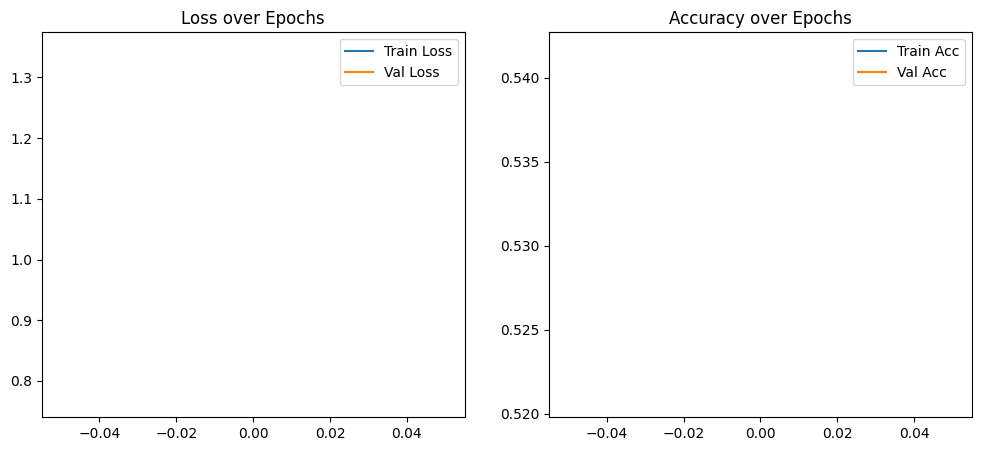

In [9]:
# Plotting Results
if 'history' in locals() and len(history['train_loss']) > 0:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title('Accuracy over Epochs')
    plt.legend()

    # Save plot
    if not os.path.exists(CHECKPOINT_DIR):
        os.makedirs(CHECKPOINT_DIR)
    plt.savefig(os.path.join(CHECKPOINT_DIR, "training_metrics.png"))
    print(f"Saved training metrics to {os.path.join(CHECKPOINT_DIR, 'training_metrics.png')}")

    plt.show()

## Explainability: Grad-CAM Visualization

To understand what the CNNs are learning, we visualize their focus areas. We apply **Grad-CAM** to the last convolutional layer of each encoder. This generates a heatmap highlighting regions that strongly influence the "ALS vs Control" decision.

**New Features:**
*   Fixed `map_fl` error.
*   Automatically selects slice with maximum activation.
*   Saves 3D NIfTI files (`.nii.gz`) for viewing in external software (ITK-SNAP, etc.).

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


Saved Grad-CAM visualization to ../cnn_features/gradcam_sample_0.png


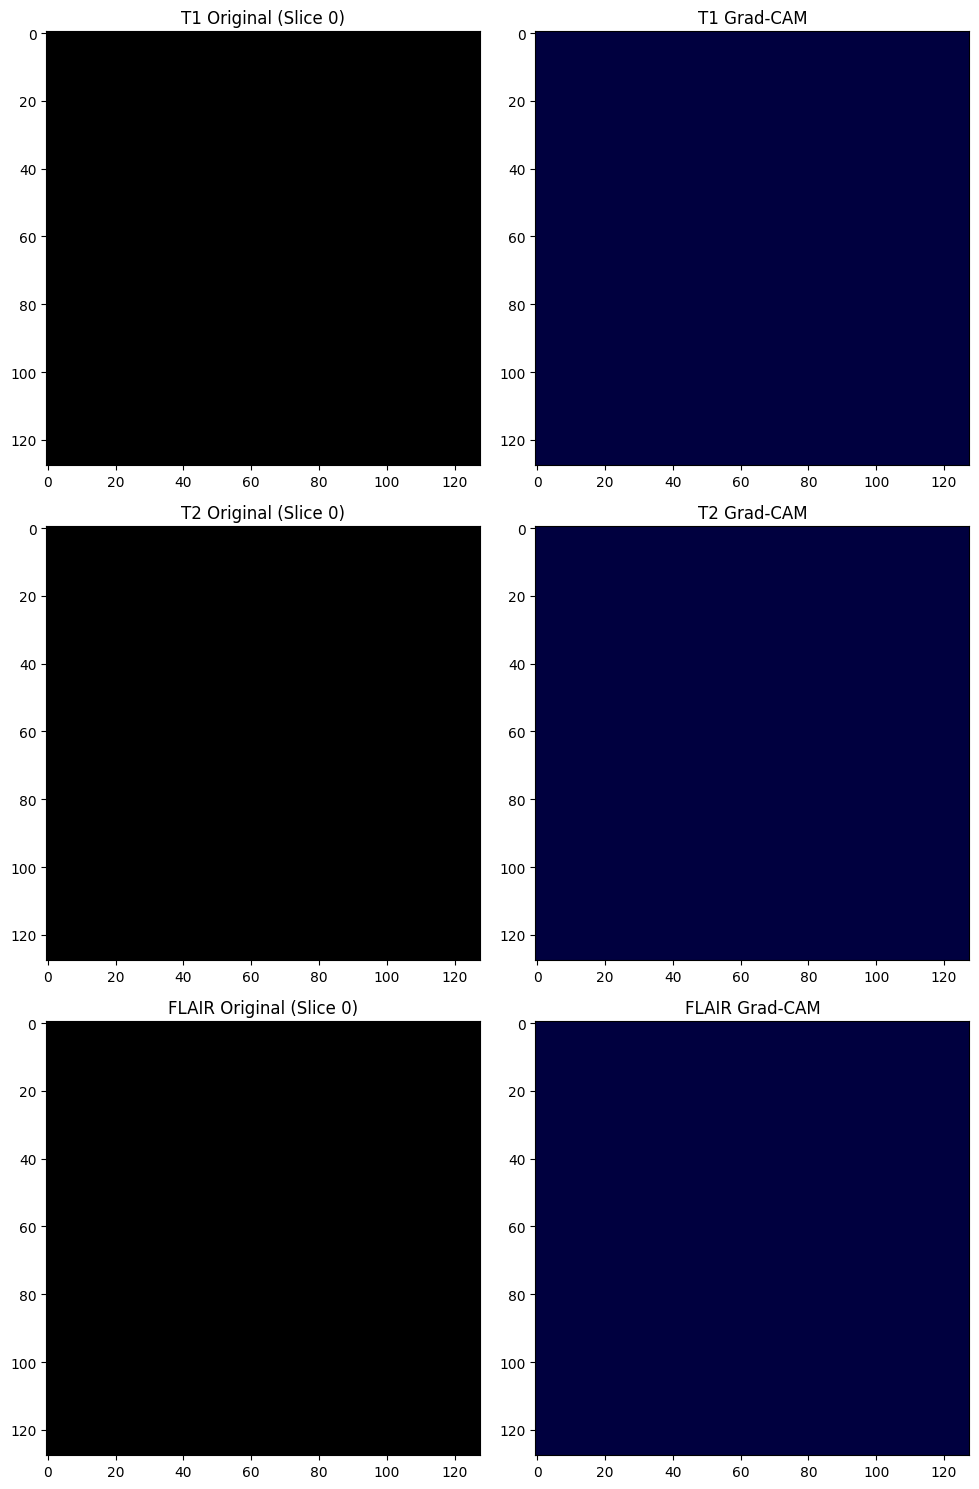

Saved 3D NIfTI files to ../cnn_features


In [10]:
class GradCAM:
    def __init__(self, model_part, target_layer):
        self.model_part = model_part
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.handle_fwd = self.target_layer.register_forward_hook(self.save_activation)
        self.handle_bwd = self.target_layer.register_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        self.handle_fwd.remove()
        self.handle_bwd.remove()

    def generate(self, x):
        # Forward pass on the specific encoder part
        output = self.model_part(x)

        # We assume we want to maximize the mean activation
        self.model_part.zero_grad()
        output.mean().backward()

        weights = torch.mean(self.gradients, dim=[0, 2, 3, 4])
        cam = torch.zeros(self.activations.shape[2:], dtype=torch.float32).to(DEVICE)

        for i, w in enumerate(weights):
            cam += w * self.activations[0, i, :, :, :]

        cam = F.relu(cam)
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        # Resize to input size
        cam = cam.unsqueeze(0).unsqueeze(0)
        cam = F.interpolate(cam, size=x.shape[2:], mode='trilinear', align_corners=False)
        return cam.squeeze().detach().cpu().numpy()

def visualize_sample_and_save(model, dataset, index=0):
    model.eval()
    (t1, t2, flair), label = dataset[index]

    # Prepare inputs
    t1 = t1.unsqueeze(0).to(DEVICE).requires_grad_(True)
    t2 = t2.unsqueeze(0).to(DEVICE).requires_grad_(True)
    flair = flair.unsqueeze(0).to(DEVICE).requires_grad_(True)

    try:
        # Access internal encoders.
        # ALSTriStreamClassifier has 'model' which is CascadedMixingTransformer
        # CascadedMixingTransformer has: t1Encoder, t2Encoder, flairEncoder
        enc_t1 = model.model.t1Encoder
        enc_t2 = model.model.t2Encoder
        enc_flair = model.model.flairEncoder

        gcam_t1 = GradCAM(enc_t1, enc_t1.block4[0])
        gcam_t2 = GradCAM(enc_t2, enc_t2.block4[0])
        gcam_flair = GradCAM(enc_flair, enc_flair.block4[0])

        # Generate Heatmaps
        map_t1 = gcam_t1.generate(t1)
        map_t2 = gcam_t2.generate(t2)
        map_flair = gcam_flair.generate(flair)

        # --- Plotting ---
        # Slice Selection: Choose slice with highest total activation
        slice_idx_t1 = np.argmax(np.sum(map_t1, axis=(1, 2)))
        slice_idx_t2 = np.argmax(np.sum(map_t2, axis=(1, 2)))
        slice_idx_fl = np.argmax(np.sum(map_flair, axis=(1, 2)))

        fig, axes = plt.subplots(3, 2, figsize=(10, 15))

        # T1
        img_t1_slice = t1.squeeze().detach().cpu().numpy()[slice_idx_t1]
        mask_t1_slice = map_t1[slice_idx_t1]
        axes[0,0].imshow(img_t1_slice, cmap='gray'); axes[0,0].set_title(f"T1 Original (Slice {slice_idx_t1})")
        axes[0,1].imshow(img_t1_slice, cmap='gray')
        axes[0,1].imshow(mask_t1_slice, cmap='jet', alpha=0.5)
        axes[0,1].set_title("T1 Grad-CAM")

        # T2
        img_t2_slice = t2.squeeze().detach().cpu().numpy()[slice_idx_t2]
        mask_t2_slice = map_t2[slice_idx_t2]
        axes[1,0].imshow(img_t2_slice, cmap='gray'); axes[1,0].set_title(f"T2 Original (Slice {slice_idx_t2})")
        axes[1,1].imshow(img_t2_slice, cmap='gray')
        axes[1,1].imshow(mask_t2_slice, cmap='jet', alpha=0.5)
        axes[1,1].set_title("T2 Grad-CAM")

        # FLAIR
        img_fl_slice = flair.squeeze().detach().cpu().numpy()[slice_idx_fl]
        mask_fl_slice = map_flair[slice_idx_fl]
        axes[2,0].imshow(img_fl_slice, cmap='gray'); axes[2,0].set_title(f"FLAIR Original (Slice {slice_idx_fl})")
        axes[2,1].imshow(img_fl_slice, cmap='gray')
        axes[2,1].imshow(mask_fl_slice, cmap='jet', alpha=0.5)
        axes[2,1].set_title("FLAIR Grad-CAM")

        plt.tight_layout()

        # Save visualization
        if not os.path.exists(CHECKPOINT_DIR):
            os.makedirs(CHECKPOINT_DIR)
        save_path = os.path.join(CHECKPOINT_DIR, f"gradcam_sample_{index}.png")
        plt.savefig(save_path)
        print(f"Saved Grad-CAM visualization to {save_path}")
        plt.show()

        # --- Save 3D NIfTI Volumes ---
        affine = np.eye(4)
        def save_nifti(data, name):
            img = nib.Nifti1Image(data, affine)
            nib.save(img, os.path.join(CHECKPOINT_DIR, name))

        save_nifti(map_t1, f"gradcam_sample_{index}_t1_heatmap.nii.gz")
        save_nifti(map_t2, f"gradcam_sample_{index}_t2_heatmap.nii.gz")
        save_nifti(map_flair, f"gradcam_sample_{index}_flair_heatmap.nii.gz")

        save_nifti(t1.squeeze().detach().cpu().numpy(), f"gradcam_sample_{index}_t1_orig.nii.gz")
        save_nifti(t2.squeeze().detach().cpu().numpy(), f"gradcam_sample_{index}_t2_orig.nii.gz")
        save_nifti(flair.squeeze().detach().cpu().numpy(), f"gradcam_sample_{index}_flair_orig.nii.gz")
        print(f"Saved 3D NIfTI files to {CHECKPOINT_DIR}")

        # Cleanup
        gcam_t1.remove_hooks()
        gcam_t2.remove_hooks()
        gcam_flair.remove_hooks()

    except Exception as e:
        print(f"Error in Grad-CAM: {e}")

# Visualize
if 'dataset' in locals() and len(dataset) > 0:
    visualize_sample_and_save(model, dataset, index=0)